# DC Servo Motor — 2nd Order System with Inertia

This notebook models a DC servo motor as a 2nd-order dynamical system (states: angle and angular velocity), simulates its open-loop step response, and designs both **PID** and **LQR** controllers for closed-loop angle tracking.

## 1. Import Required Libraries

Import numpy, AILibs, and matplotlib. These are needed for matrix operations, dynamical system simulation, controller design, and plotting.

In [1]:
import numpy
import AILibs
import matplotlib.pyplot as plt

## 2. Define the Servo Model (2nd Order System)

The `ServoModel` class inherits from `AILibs.DynamicalSystem`. The continuous-time state-space matrices are:

$$A = \begin{bmatrix} 0 & 1 \\ 0 & -1/\tau \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ k/\tau \end{bmatrix}$$

where $\tau$ is the motor time constant and $k$ is the gain. The state vector is $x = [\theta,\; \dot{\theta}]^T$ (angle and angular velocity).

We instantiate the model with example parameters $\tau = 0.5$, $k = 0.3$, and $dt = 0.01$.

In [2]:
class ServoModel(AILibs.DynamicalSystem):

    def __init__(self, tau, k, dt):
        a_tmp = -1.0 / tau
        b_tmp = k * 1.0 / tau

        a_mat = numpy.array([[0.0, 1.0], [0.0, a_tmp]])
        b_mat = numpy.array([[0.0], [b_tmp]])

        AILibs.DynamicalSystem.__init__(self, a_mat, b_mat, None, dt)


# Model parameters
dt  = 0.01
tau = 0.5
k   = 0.3

# Create dynamical system
ds = ServoModel(tau, k, dt)

# Print system matrices
print(str(ds))

mat_a = 
0.0 1.0 
0.0 -2.0 


mat_b = 
0.0 
0.6 


mat_c = 
1.0 0.0 
0.0 1.0 





## 3. Open-Loop Step Response Simulation

Simulate the servo model for 1000 steps with a unit step input applied after 10 % of the simulation. Log time, input voltage, angle (converted to degrees), and angular velocity (converted to RPM) using the scaling:

$$x_{\text{res}} = x \cdot 2\pi, \qquad \theta_{\text{deg}} = x_{\text{res},0} \cdot 360, \qquad \dot{\theta}_{\text{rpm}} = x_{\text{res},1} \cdot 60$$

<Figure size 640x480 with 0 Axes>

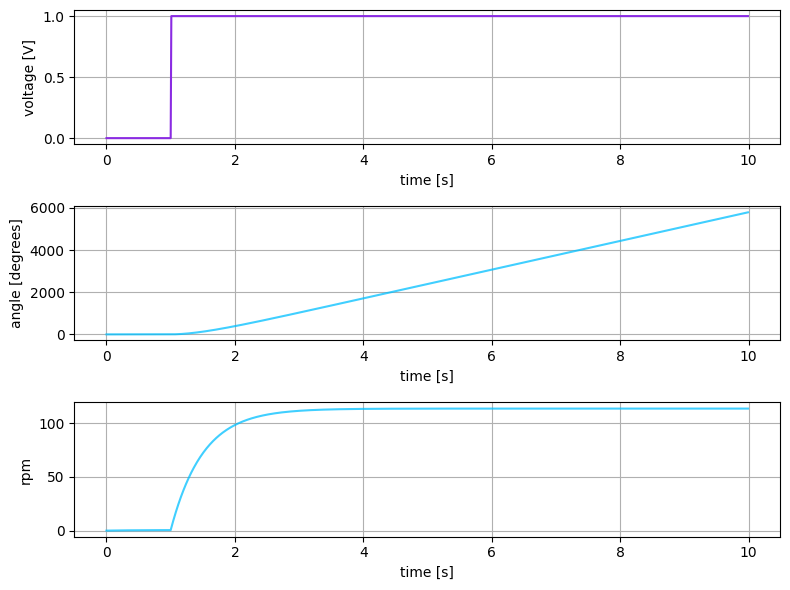

In [3]:
n_steps = 1000

t_result = []
u_result = []
x_result = []

x = numpy.zeros((ds.a.shape[0], 1))

for n in range(n_steps):
    if n > n_steps * 0.1:
        u = 1.0
    else:
        u = 0.0

    u_in = numpy.array([[u]])

    # Process simulation step
    x, _ = ds.forward(x, u_in)

    # Convert to degrees and RPM
    x_res = x * 2.0 * numpy.pi
    x_res[0, 0] *= 360.0
    x_res[1, 0] *= 60.0

    # Log results
    t_result.append(n * dt)
    u_result.append(u_in[:, 0])
    x_result.append(x_res[:, 0])

AILibs.plot_response(
    t_result, u_result, x_result,
    "plots/servo_response.png",
    ["voltage [V]"],
    ["angle [degrees]", "rpm"],
)

## 4. PID Controller Design and Closed-Loop Simulation

Design a PID controller with gains $k_p = 4.0$, $k_i = 0.0$, $k_d = 50.0$. The controller operates on the **scalar angle error** and tracks a 1000-degree angle reference that steps on at 10 % and off at 70 % of the simulation.

PID  — input cost: 1425.91  tracking cost: 117656562.151


<Figure size 640x480 with 0 Axes>

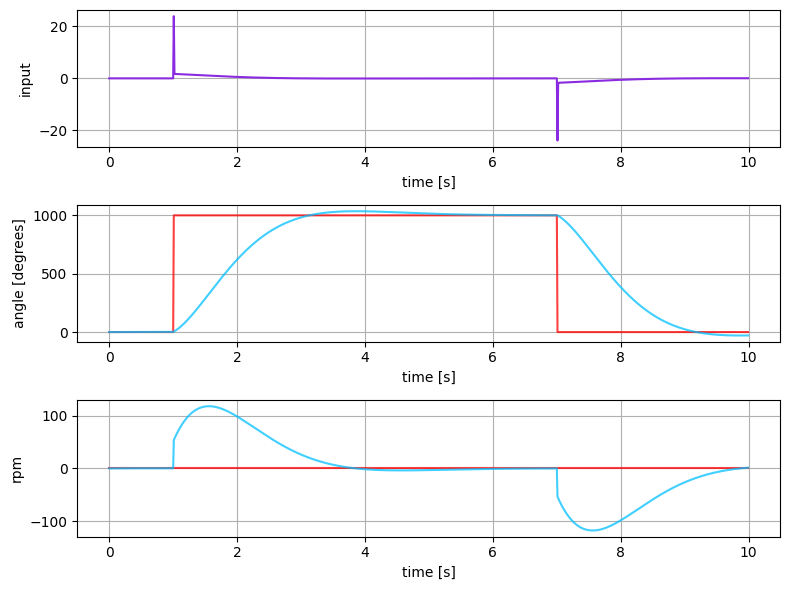

In [4]:
def compute_cost(x):
    return numpy.sum(numpy.square(x))


# PID gains
kp = 4.0
ki = 0.0
kd = 50.0
pid_controller = AILibs.PID(kp, ki, kd)

# Re-create the plant for a fresh simulation
ds_pid = ServoModel(tau, k, dt)

n_steps = 1000
angle_req = 1000  # degrees

t_pid = []
u_pid = []
xr_pid = []
x_pid = []

x = numpy.zeros((ds_pid.a.shape[0], 1))
u = 0.0

for n in range(n_steps):
    # Reference signal
    if n > n_steps * 0.7:
        xr = numpy.zeros(x.shape)
    elif n > n_steps * 0.1:
        xr = numpy.ones(x.shape)
    else:
        xr = numpy.zeros(x.shape)

    xr[1, 0] = 0
    xr = xr * angle_req / (2.0 * numpy.pi * 360)

    # PID takes scalar inputs
    u = pid_controller.forward(xr[0, 0], x[0, 0], u)

    # Process simulation step
    u_in = numpy.array([[u]])
    x, _ = ds_pid.forward(x, u_in)

    # Convert to degrees and RPM
    xr_res = xr * 2.0 * numpy.pi
    xr_res[0, 0] *= 360.0
    xr_res[1, 0] *= 60.0

    x_res = x * 2.0 * numpy.pi
    x_res[0, 0] *= 360.0
    x_res[1, 0] *= 60.0

    # Log results
    t_pid.append(n * dt)
    u_pid.append(u_in[:, 0])
    xr_pid.append(xr_res)
    x_pid.append(x_res)

AILibs.plot_cl_response(
    t_pid, u_pid, xr_pid, x_pid,
    "plots/pid_result.png",
    ["input"],
    ["angle [degrees]", "rpm"],
)

pid_u_cost = compute_cost(numpy.array(u_pid))
pid_x_cost = compute_cost(numpy.array(xr_pid) - numpy.array(x_pid))
print("PID  — input cost:", round(pid_u_cost, 3), " tracking cost:", round(pid_x_cost, 3))

## 5. LQR Controller Design and Closed-Loop Simulation

Discretize the continuous system using `AILibs.c2d`, then design an LQR controller with integral action via `AILibs.LQRIDiscrete`.

Weight matrices: $Q = \operatorname{diag}(1,\; 0)$, $R = \operatorname{diag}(1)$.

The LQR controller outputs a vector control input and maintains an integral-action state.

A_d =
 [[1.         0.00990099]
 [0.         0.98019802]]
B_d =
 [[2.97029703e-05]
 [5.94059406e-03]]
k  = [[53.79105754 10.42630178]]
ki = [[1.03127891 0.        ]]
LQR  — input cost: 337.394  tracking cost: 178983360.473


<Figure size 640x480 with 0 Axes>

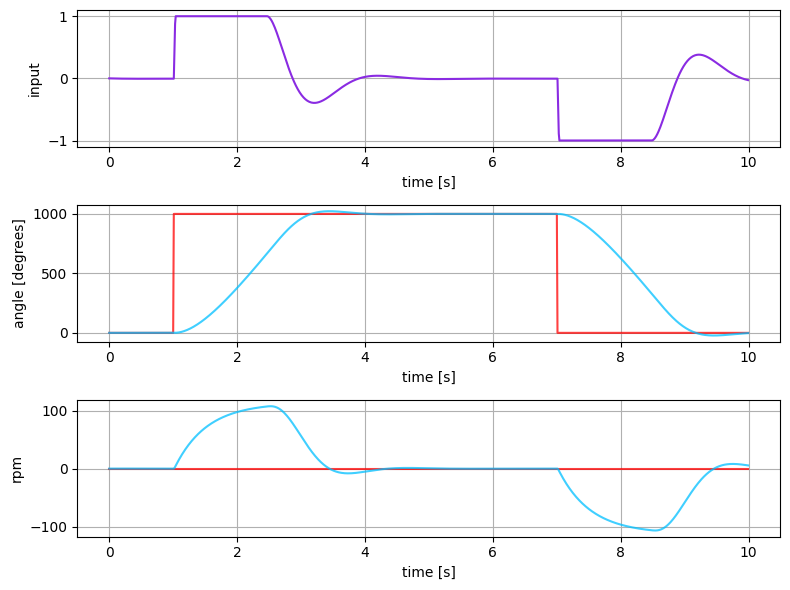

In [5]:
# Discretise continuous system
a_disc, b_disc, _ = AILibs.c2d(ds.a, ds.b, None, dt)

print("A_d =\n", a_disc)
print("B_d =\n", b_disc)

# LQR weight matrices
q = numpy.diag([1.0, 0.0])
r = numpy.diag([1.0])

lqr_controller = AILibs.LQRIDiscrete(a_disc, b_disc, q, r, 1.0)

print("k  =", lqr_controller.k)
print("ki =", lqr_controller.ki)

# Re-create plant
ds_lqr = ServoModel(tau, k, dt)

n_steps = 1000
angle_req = 1000

t_lqr = []
u_lqr = []
xr_lqr = []
x_lqr = []

x = numpy.zeros((ds_lqr.a.shape[0], 1))
integral_action = numpy.zeros((ds_lqr.b.shape[1], 1))

for n in range(n_steps):
    # Reference signal
    if n > n_steps * 0.7:
        xr = numpy.zeros(x.shape)
    elif n > n_steps * 0.1:
        xr = numpy.ones(x.shape)
    else:
        xr = numpy.zeros(x.shape)

    xr[1, 0] = 0
    xr = xr * angle_req / (2.0 * numpy.pi * 360)

    # LQR control step
    u, integral_action = lqr_controller.forward(xr, x, integral_action)

    # Process simulation step
    x, _ = ds_lqr.forward(x, u)

    # Convert to degrees and RPM
    xr_res = xr * 2.0 * numpy.pi
    xr_res[0, 0] *= 360.0
    xr_res[1, 0] *= 60.0

    x_res = x * 2.0 * numpy.pi
    x_res[0, 0] *= 360.0
    x_res[1, 0] *= 60.0

    # Log results
    t_lqr.append(n * dt)
    u_lqr.append(u[:, 0])
    xr_lqr.append(xr_res)
    x_lqr.append(x_res)

AILibs.plot_cl_response(
    t_lqr, u_lqr, xr_lqr, x_lqr,
    "plots/lqr_result.png",
    ["input"],
    ["angle [degrees]", "rpm"],
)

lqr_u_cost = compute_cost(numpy.array(u_lqr))
lqr_x_cost = compute_cost(numpy.array(xr_lqr) - numpy.array(x_lqr))
print("LQR  — input cost:", round(lqr_u_cost, 3), " tracking cost:", round(lqr_x_cost, 3))

## 6. Compare Controller Performance (Cost Metrics)

We compare the two controllers using:

- **Input cost** $J_u = \sum u^2$ — penalises large control effort.
- **Tracking error cost** $J_x = \sum (x_r - x)^2$ — penalises deviation from the reference.

Lower is better in both cases.

In [6]:
print(f"{'Controller':<12} {'Input Cost Ju':>14} {'Tracking Cost Jx':>18}")
print("-" * 48)
print(f"{'PID':<12} {round(pid_u_cost, 3):>14} {round(pid_x_cost, 3):>18}")
print(f"{'LQR':<12} {round(lqr_u_cost, 3):>14} {round(lqr_x_cost, 3):>18}")

Controller    Input Cost Ju   Tracking Cost Jx
------------------------------------------------
PID                 1425.91      117656562.151
LQR                 337.394      178983360.473
